## LG SOC Prediction - Deep Neural Net (DNN)
LG 18650HG2 Li-ion Battery Data - https://data.mendeley.com/datasets/cp3473x7xv/3

In [1]:
import os
import sys
import IPython
import IPython.display
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import collections
from datetime import datetime, timedelta

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


from sklearn.preprocessing import MinMaxScaler
import pickle
import warnings
warnings.filterwarnings('ignore')

cell_type = "lg"
model_type = "dnn_model"
base_path = '../../'

sys.path.append(base_path)
from training import utils

panasonic_data_path = base_path + 'datasets/Panasonic_18650PF'
lg_data_path = base_path + 'datasets/LG_18650HG2'
pre_trained_path = base_path + 'pre-trained/' + cell_type + '_' + model_type

resample_1hz = True
vi_averages = True

## LG Test, Train Processing

In [2]:
lg_charge_cycles = ['Charge']

lg_train_temps = ['n10degC', '0degC', '10degC', '25degC']
lg_train_discharge_cycles = ['Mixed']

lg_test_temps = ['n10degC', '0degC', '10degC', '25degC']
lg_test_discharge_cycles = ['UDDS', 'HWFET', 'LA92', 'US06']

lg_train_files = utils.lg_get_files(lg_data_path, 
                                    lg_train_discharge_cycles, 
                                    lg_charge_cycles, 
                                    lg_train_temps)

lg_test_files = utils.lg_get_files(lg_data_path, 
                                   lg_test_discharge_cycles,
                                   lg_charge_cycles, 
                                   lg_test_temps)

lg_train, lg_train_norm = utils.lg_create_dataset(lg_train_files, 
                                                  lg_train_discharge_cycles, 
                                                  lg_charge_cycles, 
                                                  vi_averages, 
                                                  resample_1hz)

lg_test, lg_test_norm = utils.lg_create_dataset(lg_test_files, 
                                                lg_test_discharge_cycles, 
                                                lg_charge_cycles, 
                                                vi_averages, 
                                                resample_1hz)

../../datasets/LG_18650HG2/25degC/551_Mixed1.csv 77227
../../datasets/LG_18650HG2/25degC/551_Mixed2.csv 79172
../../datasets/LG_18650HG2/25degC/552_Mixed3.csv 73827
../../datasets/LG_18650HG2/25degC/552_Mixed4.csv 80850
../../datasets/LG_18650HG2/25degC/552_Mixed5.csv 72184
../../datasets/LG_18650HG2/25degC/552_Mixed6.csv 78106
../../datasets/LG_18650HG2/25degC/552_Mixed7.csv 73235
../../datasets/LG_18650HG2/25degC/552_Mixed8.csv 85915
../../datasets/LG_18650HG2/10degC/567_Mixed1.csv 72329
../../datasets/LG_18650HG2/10degC/567_Mixed2.csv 77752
../../datasets/LG_18650HG2/10degC/571_Mixed4.csv 73929
../../datasets/LG_18650HG2/10degC/571_Mixed5.csv 67174
../../datasets/LG_18650HG2/10degC/571_Mixed6.csv 73921
../../datasets/LG_18650HG2/10degC/571_Mixed7.csv 69325
../../datasets/LG_18650HG2/10degC/571_Mixed8.csv 81422
../../datasets/LG_18650HG2/0degC/589_Mixed1.csv 67312
../../datasets/LG_18650HG2/0degC/589_Mixed2.csv 72303
../../datasets/LG_18650HG2/0degC/590_Mixed4.csv 68027
../../dataset

## LG Train, Test Stats

In [3]:
lg_train.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Time Stamp,,,,,,,,
Voltage,176334.0,3.665063,0.262172,2.792680,3.494900,3.672220,3.859490,4.200630
Current,176334.0,-1.333758,2.561152,-17.822440,-2.556640,-0.950120,-0.097060,5.999610
Temperature,176334.0,7.891981,12.526156,-9.884900,-0.315480,9.359110,23.976150,26.289630
Power,176334.0,-4.596105,8.941956,-50.862673,-9.210683,-3.477834,-0.386161,25.171220
Capacity,176334.0,0.485778,0.267832,0.000000,0.269070,0.473796,0.715691,0.978056
Voltage Average,176334.0,3.699654,0.226606,3.094354,3.521361,3.694212,3.889611,4.139058
Current Average,176334.0,-1.296481,0.711963,-3.715850,-1.720026,-1.162827,-0.772447,-0.277316
Power Average,176334.0,-4.522300,2.410210,-11.429077,-5.996818,-4.127167,-2.722423,-1.079428


In [4]:
lg_test.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Time Stamp,,,,,,,,
Voltage,104485.0,3.677951,0.261341,2.794030,3.496920,3.689080,3.885750,4.200120
Current,104485.0,-1.098654,2.357463,-17.610450,-2.191410,-0.625750,-0.084280,5.999610
Temperature,104485.0,6.921388,12.063139,-10.095220,-0.420630,9.148790,23.765830,26.815430
Power,104485.0,-3.776420,8.243404,-50.864924,-7.916661,-2.317480,-0.316026,25.142453
Capacity,104485.0,0.484375,0.267702,0.000000,0.258278,0.494788,0.714165,0.955909
Voltage Average,104485.0,3.704737,0.229296,3.049658,3.523629,3.716103,3.900654,4.110299
Current Average,104485.0,-1.097331,0.728330,-3.810095,-1.335683,-0.867386,-0.523847,-0.311306
Power Average,104485.0,-3.824287,2.439860,-11.887300,-4.544482,-3.073238,-1.888219,-1.210706


## LG Dataset Figures, Distribution

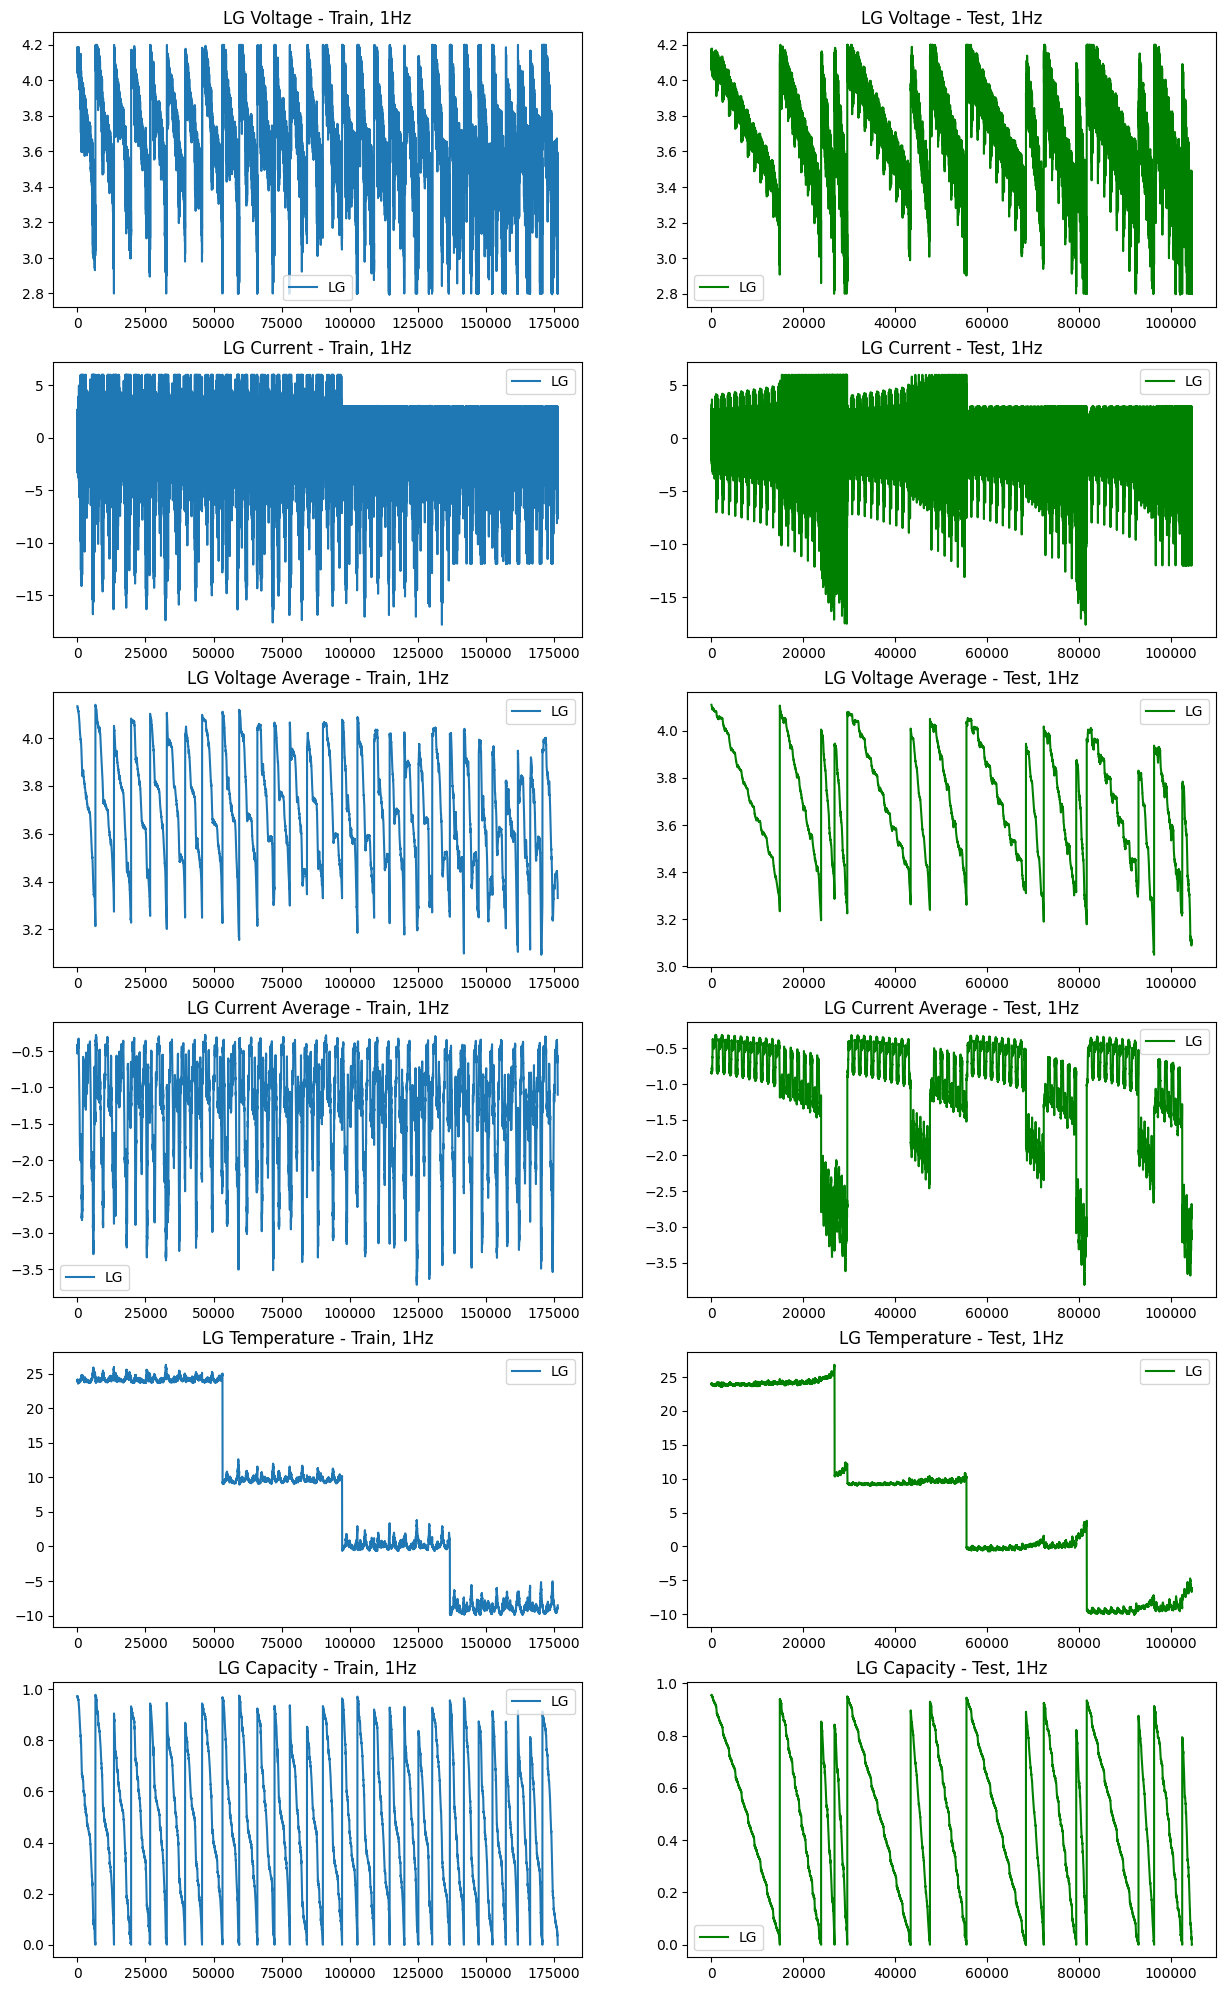

In [5]:
plot_cols = ['Voltage', 'Current', 'Voltage Average', 'Current Average', 'Temperature', 'Capacity']

fig, axs = plt.subplots(nrows=len(plot_cols), ncols=2, figsize=(15, 25))

for i, col in enumerate(plot_cols):
    axs[i, 0].plot(lg_train[col], label='LG')
    axs[i, 0].set_title(f'LG {col} - Train, 1Hz')
    axs[i, 0].legend()
    
    axs[i, 1].plot(lg_test[col], label='LG', color="green")
    axs[i, 1].set_title(f'LG {col} - Test, 1Hz')
    axs[i, 1].legend()

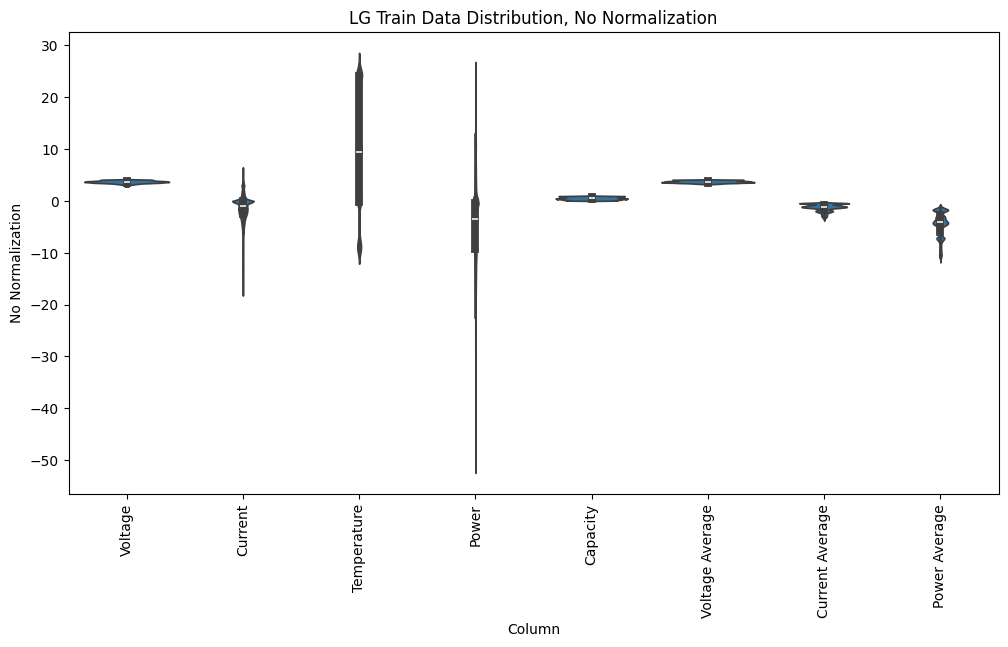

In [6]:
df_std = lg_train.melt(var_name='Column', value_name='No Normalization')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='No Normalization', data=df_std)
_ = ax.set_xticklabels(lg_train.keys(), rotation=90)
_ = ax.set_title(label='LG Train Data Distribution, No Normalization')

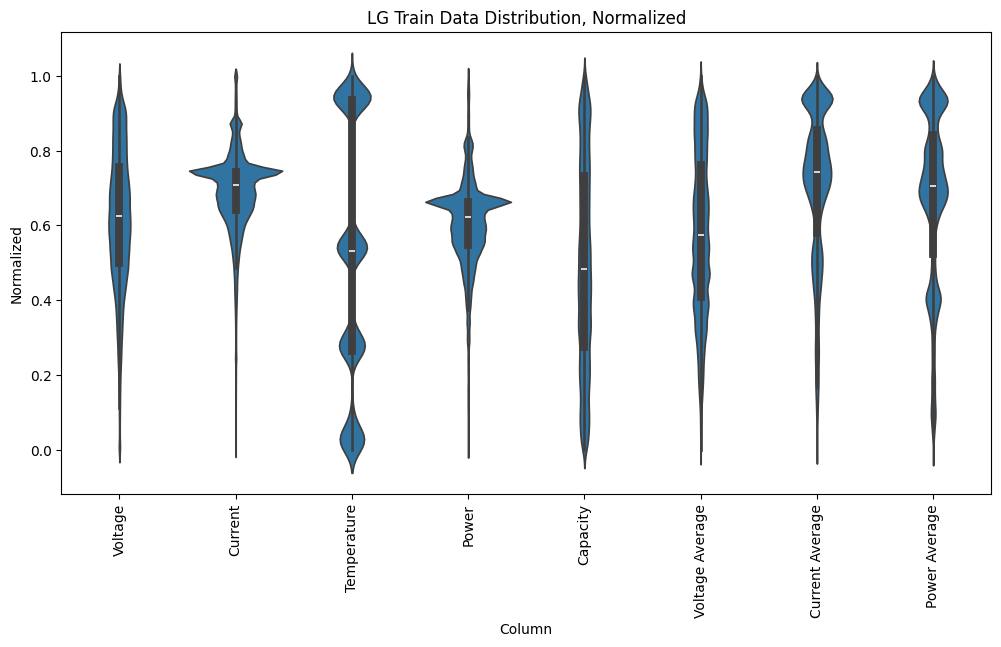

In [7]:
df_std = lg_train_norm.melt(var_name='Column', value_name='Normalized')
plt.figure(figsize=(12, 6))
ax = sns.violinplot(x='Column', y='Normalized', data=df_std)
_ = ax.set_xticklabels(lg_train_norm.keys(), rotation=90)
_ = ax.set_title(label='LG Train Data Distribution, Normalized')

Text(0.5, 1.01, 'Pair Plot, LG Training Dataset')

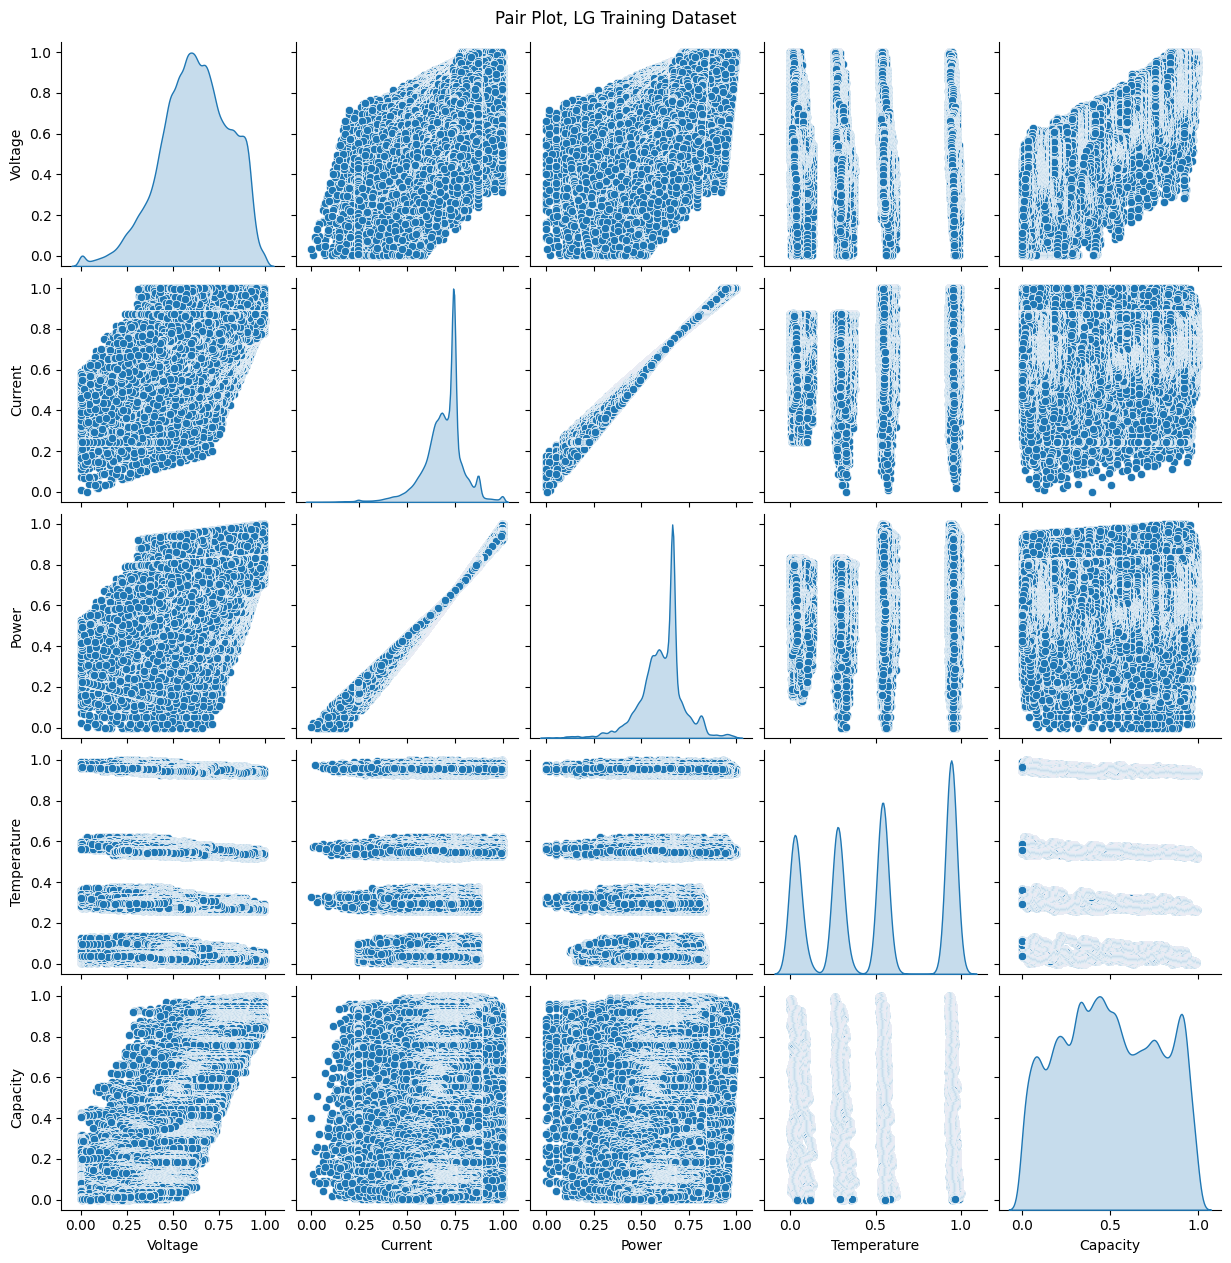

In [8]:
ax = sns.pairplot(lg_train_norm[['Voltage', 'Current', 'Power', 'Temperature', 'Capacity']], diag_kind='kde')
ax.fig.suptitle("Pair Plot, LG Training Dataset", y = 1.01) 

## DNN MODEL TRAINING

In [9]:
train_features = lg_train_norm
test_features = lg_test_norm

train_labels = train_features.pop('Capacity')
test_labels = test_features.pop('Capacity')

In [10]:
dnn_model = tf.keras.Sequential([
      layers.Dense(64, activation='relu', input_shape=(train_features.shape[1],)),
      layers.Dense(64, activation='relu'),
      layers.Dense(1)
      ])

dnn_model.compile(loss='mean_absolute_error', 
                  optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), metrics=['mse', 'mae', 'mape', tf.keras.metrics.RootMeanSquaredError(name='rmse')])

dnn_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                512       
                                                                 
 dense_1 (Dense)             (None, 64)                4160      
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 4,737
Trainable params: 4,737
Non-trainable params: 0
_________________________________________________________________


In [11]:
%%time
history = dnn_model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=1, epochs=25)

Epoch 1/25
4409/4409 [==============================] - 20s 4ms/step - loss: 0.0162 - mse: 0.0013 - mae: 0.0162 - mape: 12.3174 - rmse: 0.0366 - val_loss: 0.0288 - val_mse: 0.0012 - val_mae: 0.0288 - val_mape: 1085.4414 - val_rmse: 0.0348
Epoch 2/25
4409/4409 [==============================] - 22s 5ms/step - loss: 0.0104 - mse: 1.8445e-04 - mae: 0.0104 - mape: 7.8595 - rmse: 0.0136 - val_loss: 0.0182 - val_mse: 5.6387e-04 - val_mae: 0.0182 - val_mape: 1792.7107 - val_rmse: 0.0237
Epoch 3/25
4409/4409 [==============================] - 30s 7ms/step - loss: 0.0094 - mse: 1.5308e-04 - mae: 0.0094 - mape: 6.5820 - rmse: 0.0124 - val_loss: 0.0193 - val_mse: 6.0449e-04 - val_mae: 0.0193 - val_mape: 1441.2866 - val_rmse: 0.0246
Epoch 4/25
4409/4409 [==============================] - 19s 4ms/step - loss: 0.0089 - mse: 1.3840e-04 - mae: 0.0089 - mape: 6.3602 - rmse: 0.0118 - val_loss: 0.0245 - val_mse: 9.1398e-04 - val_mae: 0.0245 - val_mape: 1329.7532 - val_rmse: 0.0302
Epoch 5/25
4409/4409 [=

## SAVE MODEL, EVALUATE

In [12]:
# Save as SavedModel (folder format)
dnn_model.save(pre_trained_path)
print(f"Model saved in TensorFlow SavedModel format at: {pre_trained_path}")

# Save as .h5 (Flask / lightweight format)
h5_path = pre_trained_path + ".h5"
dnn_model.save(h5_path)
print(f"Model also saved in H5 format at: {h5_path}")

# Save scaler (MinMaxScaler / StandardScaler) used on training features
train_scaler = MinMaxScaler()
train_features_scaled = train_scaler.fit_transform(train_features)

scaler_path = pre_trained_path + "_scaler.pkl"
with open(scaler_path, "wb") as f:
    pickle.dump(train_scaler, f)  # train_scaler = scaler.fit(train_features)


INFO:tensorflow:Assets written to: ../../pre-trained/lg_dnn_model\assets
Model saved in TensorFlow SavedModel format at: ../../pre-trained/lg_dnn_model
Model also saved in H5 format at: ../../pre-trained/lg_dnn_model.h5


In [13]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,mse,mae,mape,rmse,val_loss,val_mse,val_mae,val_mape,val_rmse,epoch
20,0.007072,0.000096,0.007072,5.312051,0.009774,0.015145,0.000422,0.015145,1759.554199,0.020543,20
21,0.007050,0.000095,0.007050,5.054795,0.009759,0.014893,0.000415,0.014893,851.605164,0.020380,21
22,0.006916,0.000092,0.006916,5.262012,0.009604,0.018558,0.000602,0.018558,769.680054,0.024533,22
23,0.006902,0.000092,0.006902,5.052851,0.009591,0.015715,0.000462,0.015715,332.487183,0.021494,23
24,0.006822,0.000090,0.006822,4.935191,0.009505,0.015545,0.000448,0.015545,268.612701,0.021164,24


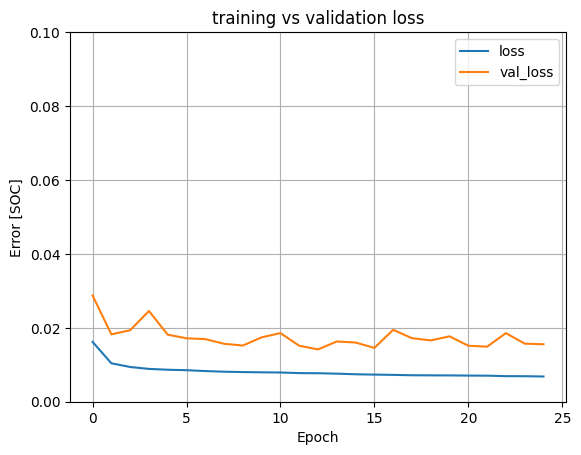

In [14]:
def plot_loss(history):
    plt.plot(history.history['loss'], label='loss')
    plt.plot(history.history['val_loss'], label='val_loss')
    plt.ylim([0, 0.1])
    plt.xlabel('Epoch') 
    plt.ylabel('Error [SOC]')
    plt.title('training vs validation loss')
    plt.legend()
    plt.grid(True)
    
plot_loss(history)

## Testing

3266/3266 - 8s - loss: 0.0232 - mse: 8.1873e-04 - mae: 0.0232 - mape: 294.1982 - rmse: 0.0286 - 8s/epoch - 2ms/step
3266/3266 [==============================] - 13s 4ms/step


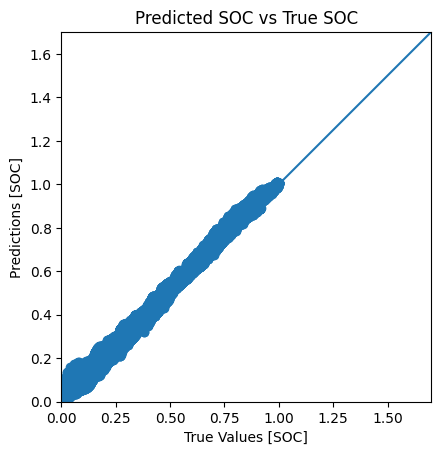

In [15]:
test_results = dnn_model.evaluate(test_features, test_labels, verbose=2)
test_predictions = dnn_model.predict(test_features).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [SOC]')
plt.ylabel('Predictions [SOC]')
lims = [0, 1.7]
plt.xlim(lims)
plt.ylim(lims)
plt.title('Predicted SOC vs True SOC')
_ = plt.plot(lims, lims)

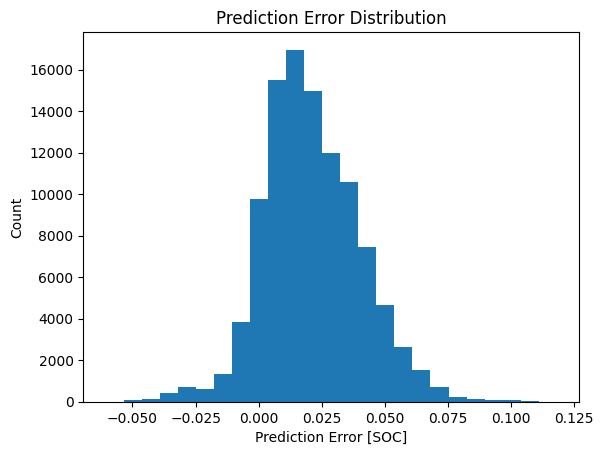

In [16]:
error = test_predictions - test_labels
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [SOC]')
plt.title('Prediction Error Distribution')
_ = plt.ylabel('Count')

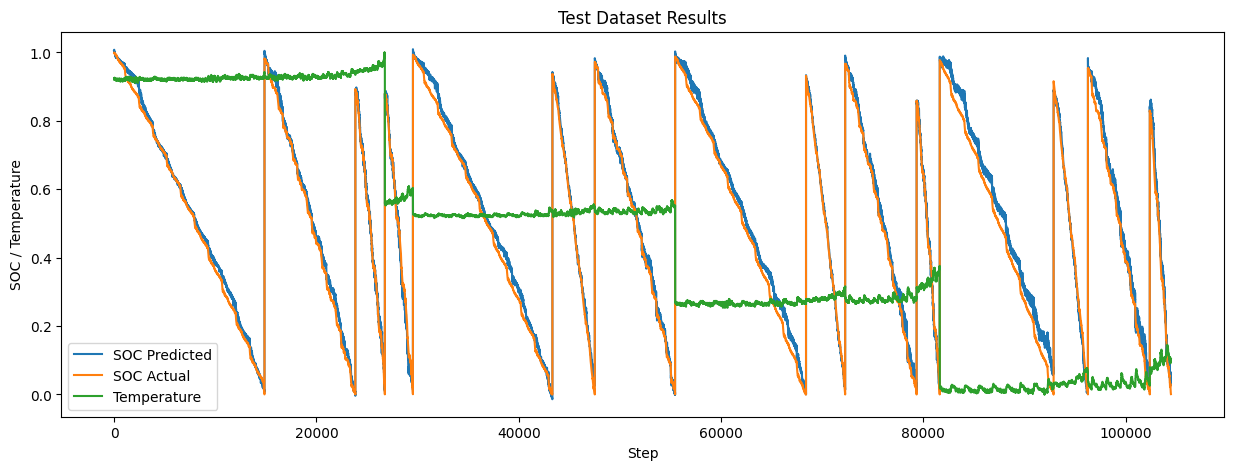

In [18]:
import numpy as np
import matplotlib.pyplot as plt

steps_num = len(test_predictions)
step_index = np.arange(steps_num)

plt.figure(figsize=(15,5))
plt.plot(step_index, test_predictions, label='SOC Predicted')
plt.plot(step_index, test_labels, label='SOC Actual')
plt.plot(step_index, lg_test_norm['Temperature'][:steps_num], label='Temperature')
plt.xlabel('Step')
plt.ylabel('SOC / Temperature')
plt.title('Test Dataset Results')
plt.legend()
plt.show()